In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
credit_fraud = pd.read_csv('../data/credit_card_fraud_dataset.csv')
credit_fraud.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


NUMBER OF FRAUD VS NON-FRAUD TRANSACTIONS

In [3]:
credit_fraud["IsFraud"].value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

In [6]:
credit_fraud["IsFraud"].value_counts(normalize=True)*100

IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64

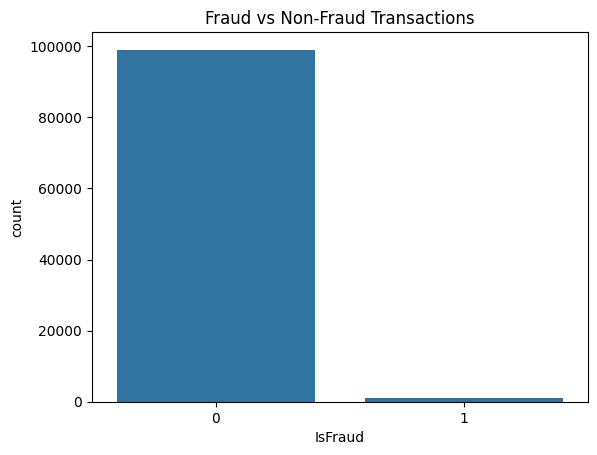

In [7]:
sns.countplot(x="IsFraud", data=credit_fraud)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

EDA QUESTIONS
1. How does fraud change over time by TransactionDate and Hour, and does that timing align with specific TransactionID ranges?
2. Are larger Amount transactions more likely to be fraudulent, and does that effect differ by TransactionType?
3. Which MerchantID values have the highest fraud rate, and are those merchants concentrated in particular Locations?
4. Does fraud occur more often in certain Locations, and do those locations also have different average transaction Amounts?
5. How does TransactionType interact with fraud across merchants: e.g. do some MerchantID and TransactionType combinations show outsized IsFraud rates?
6. Is fraud density related to the sequence of transactions via TransactionID, suggesting bursts or clusters of suspicious activity?

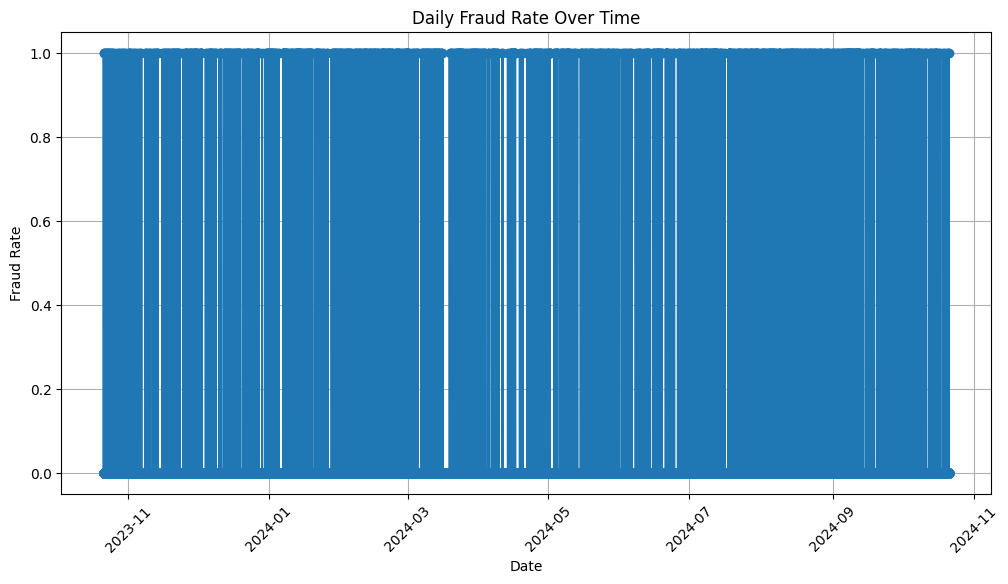

In [10]:
#QUESTION 1
credit_fraud["TransactionDate"] = pd.to_datetime(credit_fraud["TransactionDate"])
daily_fraud = credit_fraud.groupby('TransactionDate')['IsFraud'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(daily_fraud['TransactionDate'], daily_fraud['IsFraud'], marker='o')
plt.title('Daily Fraud Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Fraud Rate')
plt.xticks
plt.xticks(rotation=45)
plt.grid()


<Axes: xlabel='IsFraud', ylabel='Amount'>

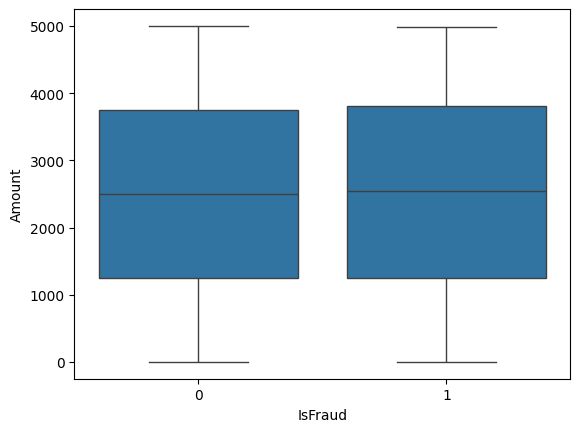

In [12]:
#QUESTION 2
sns.boxplot(x='IsFraud', y='Amount', data=credit_fraud)

<Axes: xlabel='fraud_rate', ylabel='TransactionType'>

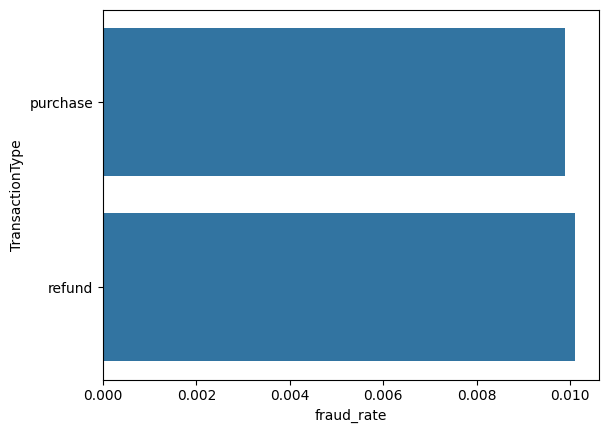

In [13]:
fraud_by_type = credit_fraud.groupby('TransactionType')['IsFraud'].mean().reset_index()
sns.barplot(x='fraud_rate', y='TransactionType', data=fraud_by_type.rename(columns={'IsFraud':'fraud_rate'}))

<Axes: xlabel='IsFraud', ylabel='MerchantID'>

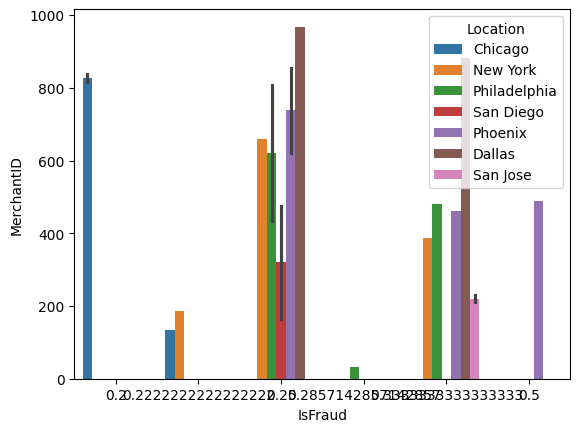

In [14]:
#QUESTION 4
fraud_by_merchant_loc = credit_fraud.groupby(['MerchantID','Location'])['IsFraud'].mean().reset_index()
top = fraud_by_merchant_loc.sort_values('IsFraud', ascending=False).head(20)
sns.barplot(x='IsFraud', y='MerchantID', hue='Location', data=top)

<Axes: xlabel='Amount', ylabel='Location'>

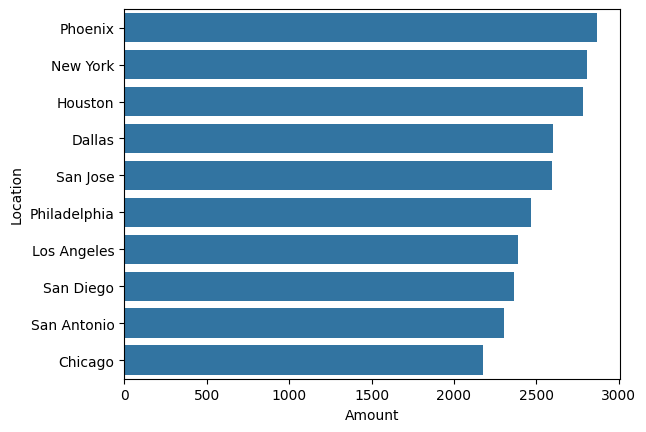

In [ ]:

fraud_locations = credit_fraud[credit_fraud['IsFraud']==1].groupby('Location')['Amount'].median().sort_values(ascending=False).reset_index()
sns.barplot(x='Amount', y='Location', data=fraud_locations)

<Axes: xlabel='block', ylabel='IsFraud'>

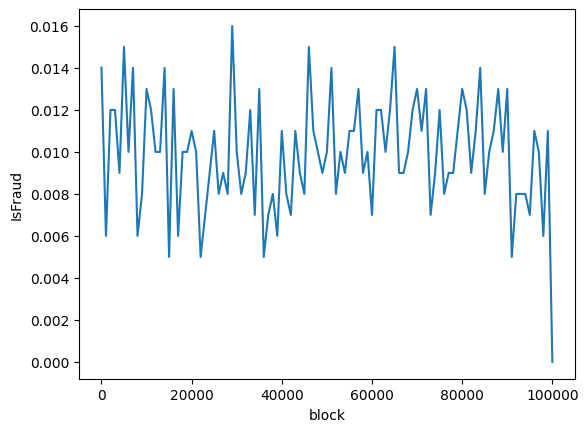

In [17]:
fraud_by_id_block = credit_fraud.assign(block=(credit_fraud['TransactionID']//1000)*1000).groupby('block')['IsFraud'].mean().reset_index()
sns.lineplot(x='block', y='IsFraud', data=fraud_by_id_block)